# Análise estatística — TechStore\n
\n
Notebook para analisar a camada Processed gerada pelo pipeline ETL.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('../data/processed/relatorio_produtos.xlsx')
df.head()

,id_produto,produto,categoria,preco_venda,fornecedor,data_atualizacao,custo_aquisicao,prazo_entrega_dias,quantidade_reposicao,status_fornecimento,margem_valor,margem_percentual
0,1,Notebook Lenovo IdeaPad,Notebooks,3299.9,Techdistribuidora,2026-09-15,2450,7,10,Disponível,849.9,25.76
1,2,Notebook Dell Inspiron,Notebooks,4599.9,Techdistribuidora,2026-09-15,3480,8,8,Disponível,1119.9,24.35
2,3,MacBook Air M2,Notebooks,7999.9,Importadora Digital,2026-09-15,6250,15,5,Disponível,1749.9,21.87
3,4,iPhone 15,Smartphones,4999.0,Mobile Supply,2026-09-16,3820,10,12,Disponível,1179.0,23.58
4,5,Galaxy S24,Smartphones,3999.0,Mobile Supply,2026-09-16,3010,12,20,Disponível,989.0,24.73


In [6]:
df.info()
df.describe(include='all')

<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   id_produto            14 non-null     int64         
 1   produto               14 non-null     str           
 2   categoria             14 non-null     str           
 3   preco_venda           14 non-null     float64       
 4   fornecedor            14 non-null     str           
 5   data_atualizacao      14 non-null     datetime64[us]
 6   custo_aquisicao       14 non-null     int64         
 7   prazo_entrega_dias    14 non-null     int64         
 8   quantidade_reposicao  14 non-null     int64         
 9   status_fornecimento   14 non-null     str           
 10  margem_valor          14 non-null     float64       
 11  margem_percentual     14 non-null     float64       
dtypes: datetime64[us](1), float64(3), int64(4), str(4)
memory usage: 1.4 KB


,id_produto,produto,categoria,preco_venda,fornecedor,data_atualizacao,custo_aquisicao,prazo_entrega_dias,quantidade_reposicao,status_fornecimento,margem_valor,margem_percentual
count,14.0000,14,14,14.000000,14,14,14.000000,14.000000,14.000000,14,14.000000,14.000000
unique,NaN,14,5,NaN,5,NaN,NaN,NaN,NaN,1,NaN,NaN
top,NaN,Notebook Lenovo IdeaPad,Notebooks,NaN,Techdistribuidora,NaN,NaN,NaN,NaN,Disponível,NaN,NaN
freq,NaN,1,3,NaN,4,NaN,NaN,NaN,NaN,14,NaN,NaN
mean,7.5000,NaN,NaN,2251.200000,NaN,2026-09-16 17:08:34.285714,1684.428571,8.142857,16.428571,NaN,566.771429,32.174286
min,1.0000,NaN,NaN,119.900000,NaN,2026-09-15 00:00:00,65.000000,4.000000,5.000000,NaN,54.900000,21.870000
25%,4.2500,NaN,NaN,362.400000,NaN,2026-09-16 00:00:00,222.500000,6.000000,10.000000,NaN,139.900000,24.747500
50%,7.5000,NaN,NaN,1149.900000,NaN,2026-09-17 00:00:00,795.000000,7.500000,14.500000,NaN,354.900000,31.100000
75%,10.7500,NaN,NaN,3824.225000,NaN,2026-09-18 00:00:00,2870.000000,9.750000,21.500000,NaN,954.225000,38.685000
max,14.0000,NaN,NaN,7999.900000,NaN,2026-09-18 00:00:00,6250.000000,15.000000,35.000000,NaN,1749.900000,45.790000


In [9]:
estatisticas = pd.DataFrame({
    'indicador': [
        'Quantidade de produtos',
        'Preço médio',
        'Custo médio',
        'Margem média'
    ],
    'valor': [
        df['id_produto'].nunique(),
        df['preco_venda'].mean(),
        df['custo_aquisicao'].mean(),
        df['margem_percentual'].mean()
    ]
})
estatisticas

,indicador,valor
0,Quantidade de produtos,14.000000
1,Preço médio,2251.200000
2,Custo médio,1684.428571
3,Margem média,32.174286


<Figure size 1000x500 with 0 Axes>

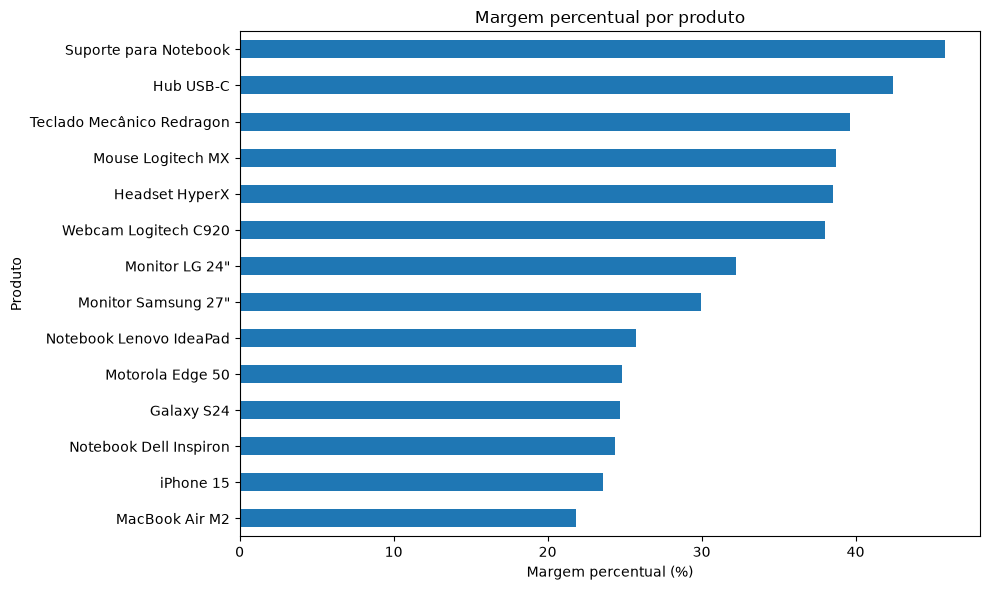

In [11]:
plt.figure(figsize=(10, 5))
df.sort_values('margem_percentual').plot(
    x='produto',
    y='margem_percentual',
    kind='barh',
    legend=False,
    figsize=(10, 6)
)
plt.title('Margem percentual por produto')
plt.xlabel('Margem percentual (%)')
plt.ylabel('Produto')
plt.tight_layout()
plt.show()